# LoRA for BERT on IMDB (Sentiment Analysis)
This notebook fine-tunes a BERT classifier on the **IMDB** dataset using **LoRA** adapters via `peft`.

**What you’ll get:**
- Baseline BERT sequence classifier (frozen base) + LoRA adapters
- Training with Hugging Face `Trainer`
- Evaluation + saving adapters and full model

Works in Colab or any Python environment with a GPU (recommended).

### High-level fine-tuning approach

We use **parameter-efficient fine-tuning** so we don’t have to train the full BERT model:

1. **Base model**  
   We start from **BERT (bert-base-uncased)** and add a classification head for binary sentiment (positive/negative). The head is randomly initialized; the rest of BERT is loaded from pretrained weights.

2. **LoRA (Low-Rank Adaptation)**  
   Instead of updating all 110M parameters, we inject small **adapter** matrices into some layers and only train those. Here we add LoRA to the **query** and **value** projections in every BERT attention layer. Each adapter is a low-rank update: the weight change is approximated by two matrices *A* and *B* (rank 8), so we train many fewer parameters than the original layer.

3. **What actually gets trained**  
   The **base BERT weights are frozen**. Only the LoRA adapter parameters and the classification head are updated. That’s about **0.27%** of the total parameters, which keeps training fast and reduces overfitting and memory use.

4. **Task and data**  
   We fine-tune on the **IMDB** sentiment dataset with a **90% train / 10% validation** stratified split (same as the encoder-only baseline for fair comparison). The model is trained with cross-entropy to predict positive vs negative, using the Hugging Face `Trainer` with a small learning rate, warmup, and weight decay.

5. **After training**  
   We can save either the **LoRA adapters only** (small, need base BERT + PEFT to load) or a **merged model** (LoRA weights merged into BERT and saved as a single checkpoint for inference without PEFT).

In short: **pretrained BERT is frozen, LoRA adapters and the classifier are trained on IMDB so the model gets good at sentiment with minimal new parameters.**

In [6]:
# If running in Colab, uncomment the next line to see your GPU
# !nvidia-smi


## 1) Install dependencies

In [11]:
!pip3 -q install -U transformers datasets accelerate evaluate peft scikit-learn
   # If using system Python 3.10, use a venv for it and run:
!pip3 install -U "transformers>=4.36" "accelerate>=0.25" "peft"


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


## 2) Imports & configuration

In [ ]:
import os
# Enable MPS fallback for ops not yet implemented on Apple Silicon
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import numpy as np
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)
import evaluate

from peft import LoraConfig, get_peft_model, TaskType


In [ ]:
# Reproducibility
set_seed(42)

# Choose a BERT checkpoint
MODEL_NAME = "bert-base-uncased"

# Output directory
OUTPUT_DIR = "./bert-imdb-lora"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Training hyperparams (tune as you like)
MAX_LENGTH = 256
BATCH_SIZE = 16
LR = 2e-4
EPOCHS = 2  # Standard for LoRA: pretrained base already encodes language; we only adapt ~0.27% of params, so 2 epochs limit overfitting and time while reaching strong accuracy.

# Use MPS (Apple Silicon) if available, else CUDA, else CPU
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print("Device:", device)


Device: mps


## 3) Load IMDB dataset

In [ ]:
from datasets import concatenate_datasets

ds = load_dataset("imdb")
# 90% train / 10% validation (stratified) for fair comparison with encoder-only model
combined = concatenate_datasets([ds["train"], ds["test"]])
split = combined.train_test_split(test_size=0.10, seed=42, stratify_by_column="label")
# split["train"] = 90%, split["test"] = 10% (we use "test" as validation)
ds = split
print(f"Train (90%): {len(ds['train']):,}  |  Val (10%): {len(ds['test']):,}")
ds


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

## 4) Tokenization

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized = ds.map(tokenize_fn, batched=True, remove_columns=["text"])
tokenized


Map: 100%|██████████| 25000/25000 [00:02<00:00, 9245.96 examples/s] 


DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 50000
    })
})

## 5) Data collator

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


## 6) Build BERT classifier + attach LoRA adapters
We add LoRA to the attention projection layers (`query` and `value`) which is a common setup for BERT-like models.

We also **freeze** the base model by default (only LoRA + classification head train).

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)

# LoRA config
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,                 # rank
    lora_alpha=16,       # scaling
    lora_dropout=0.05,
    target_modules=["query", "value"],  # BERT attention projections
    bias="none",
)

model = get_peft_model(model, lora_config)

# Optional: freeze all base weights except LoRA + classifier
# (PEFT already marks LoRA weights as trainable; the classifier head remains trainable too)
model.print_trainable_parameters()

model.to(device)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1698.38it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those p

trainable params: 296,450 || all params: 109,780,228 || trainable%: 0.2700


PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): BertForSequenceClassification(
      (bert): BertModel(
        (embeddings): BertEmbeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (token_type_embeddings): Embedding(2, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (encoder): BertEncoder(
          (layer): ModuleList(
            (0-11): 12 x BertLayer(
              (attention): BertAttention(
                (self): BertSelfAttention(
                  (query): lora.Linear(
                    (base_layer): Linear(in_features=768, out_features=768, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.05, inplace=False)
                    )
                    (lora_A): ModuleDict(
                      (default): 

## 7) Metrics

In [ ]:
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1.compute(predictions=preds, references=labels, average="weighted")["f1"],
    }


## 8) Training setup

In [ ]:
# fp16 for CUDA; MPS uses fp32 (fp16 on MPS can be unstable)
fp16 = torch.cuda.is_available()

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="steps",
    eval_steps=400,  # evaluate every 400 steps so train/val curves have many points
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    warmup_ratio=0.06,
    fp16=fp16,
    report_to="none",  # set to "wandb" if you want
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    save_total_limit=2,
)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## 9) Train

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
train_result


/Users/atin5551/Desktop/School/ECS171/Group Project/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.262551,0.230184,0.908520,0.908504
2,0.218147,0.231359,0.913120,0.913110


/Users/atin5551/Desktop/School/ECS171/Group Project/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=3126, training_loss=0.2760334348953159, metrics={'train_runtime': 1309.8663, 'train_samples_per_second': 38.172, 'train_steps_per_second': 2.387, 'total_flos': 6600510741281280.0, 'train_loss': 0.2760334348953159, 'epoch': 2.0})

### Training and validation curves

Train loss and validation loss over time, plus validation accuracy and F1 per epoch.

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

# Training loss (each logging step)
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
train_steps = [x["step"] for x in train_logs]
train_loss = [x["loss"] for x in train_logs]

# Validation metrics (each eval at end of epoch)
eval_logs = [x for x in log_history if "eval_loss" in x]
eval_epochs_raw = [x["epoch"] for x in eval_logs]
eval_loss = [x["eval_loss"] for x in eval_logs]
# Trainer may use "eval_accuracy" or "accuracy"; try both
eval_acc = [x.get("eval_accuracy", x.get("accuracy", 0)) for x in eval_logs]
eval_f1 = [x.get("eval_f1", x.get("f1", 0)) for x in eval_logs]

# Epoch x-axis: 1, 2, ... (one tick per eval)
n_epochs = len(eval_logs)
epochs_x = list(range(1, n_epochs + 1))

# Steps per epoch so we can plot train loss vs epoch
steps_per_epoch = (train_steps[-1] / n_epochs) if train_steps and n_epochs else 1
train_epochs = [s / steps_per_epoch for s in train_steps]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: train loss and val loss vs EPOCH (so both start from the same x-range)
ax1 = axes[0]
ax1.plot(train_epochs, train_loss, color="C0", alpha=0.8, label="Train loss")
if eval_logs:
    ax1.plot(epochs_x, eval_loss, "o-", color="C1", label="Val loss", markersize=10)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.set_title("Train and validation loss")
ax1.grid(True, alpha=0.3)

# Right: val accuracy and val F1 over epochs (1, 2, ...)
ax2 = axes[1]
if epochs_x:
    ax2.plot(epochs_x, eval_acc, "o-", color="C2", label="Val accuracy", markersize=10)
    ax2.plot(epochs_x, eval_f1, "s-", color="C3", label="Val F1", markersize=10)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Score")
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.set_title("Validation metrics over time")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10) Evaluate

In [ ]:
metrics = trainer.evaluate()
metrics


/Users/atin5551/Desktop/School/ECS171/Group Project/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.23135915398597717,
 'eval_accuracy': 0.91312,
 'eval_f1': 0.9131098651346692,
 'eval_runtime': 192.7553,
 'eval_samples_per_second': 129.698,
 'eval_steps_per_second': 8.109,
 'epoch': 2.0}

## 10.5) Base vs LoRA model comparison
Evaluate the **untrained base BERT** and compare with the **LoRA-fine-tuned** model.

In [ ]:
# LoRA model metrics (from trained model)
lora_metrics = trainer.evaluate()

# Load fresh base model (no LoRA, no fine-tuning) for comparison
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)
base_model.to(device)

base_trainer = Trainer(
    model=base_model,
    args=TrainingArguments(
        output_dir=os.path.join(OUTPUT_DIR, "base_eval"),
        per_device_eval_batch_size=BATCH_SIZE,
        report_to="none",
    ),
    eval_dataset=tokenized["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
base_metrics = base_trainer.evaluate()

# Comparison table
print(f"{'Metric':<18} {'Base (untrained)':<18} {'LoRA (fine-tuned)':<18} {'Δ (improvement)':<18}")
print("-" * 72)
for name, key in [("Accuracy", "eval_accuracy"), ("F1 (weighted)", "eval_f1"), ("Loss", "eval_loss")]:
    base_val = base_metrics[key]
    lora_val = lora_metrics[key]
    delta = lora_val - base_val if key != "eval_loss" else base_val - lora_val  # lower loss = better
    print(f"{name:<18} {base_val:<18.4f} {lora_val:<18.4f} {delta:+.4f}")

/Users/atin5551/Desktop/School/ECS171/Group Project/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1860.72it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXP

Metric             Base (untrained)   LoRA (fine-tuned)  Δ (improvement)   
------------------------------------------------------------------------
Accuracy           0.4998             0.9131             +0.4133
F1 (weighted)      0.3453             0.9131             +0.5678
Loss               0.7163             0.2314             +0.4849


## 11) Save LoRA adapters (recommended)

In [ ]:
# This saves only the adapter weights + config
adapter_dir = os.path.join(OUTPUT_DIR, "lora_adapter")
trainer.model.save_pretrained(adapter_dir)
tokenizer.save_pretrained(adapter_dir)
print("Saved LoRA adapter to:", adapter_dir)


Saved LoRA adapter to: ./bert-imdb-lora/lora_adapter


## 12) (Optional) Merge LoRA into base weights and save a standalone model
If you want a single model directory without PEFT adapters, you can merge the LoRA weights into the base model.

In [ ]:
from peft import PeftModel

merged_dir = os.path.join(OUTPUT_DIR, "merged_model")
os.makedirs(merged_dir, exist_ok=True)

# Merge and unload creates a regular Transformers model
merged_model = trainer.model.merge_and_unload()
merged_model.save_pretrained(merged_dir)
tokenizer.save_pretrained(merged_dir)
print("Saved merged model to:", merged_dir)


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.78it/s]

Saved merged model to: ./bert-imdb-lora/merged_model


## 13) Quick inference demo

In [ ]:
from transformers import pipeline

# device: cuda:0, mps (Apple Silicon), or -1 (CPU)
if torch.cuda.is_available():
    pipe_device = 0
elif torch.backends.mps.is_available():
    pipe_device = torch.device("mps")
else:
    pipe_device = -1

pipe = pipeline(
    "text-classification",
    model=merged_dir,      # or adapter_dir with PeftModel below
    tokenizer=tokenizer,
    device=pipe_device
)

tests = [
    "This movie was incredible. I loved every minute of it.",
    "Terrible plot, bad acting, I want my time back."
]
pipe(tests)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2538.17it/s, Materializing param=classifier.weight]                                      


[{'label': 'LABEL_1', 'score': 0.9973729848861694},
 {'label': 'LABEL_0', 'score': 0.9902955889701843}]

## 14) Loading the adapter later
If you saved only the adapter, load it like this:

In [ ]:
# Example of loading adapter (run when you need it):
# base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
# loaded = PeftModel.from_pretrained(base, adapter_dir)
# loaded.to(device)
# loaded.eval()


## 15) Load saved model, metrics (precision/recall), and visualization

Load the **merged model** from disk (no training). Evaluate on the **10% validation set** (same 90/10 split as training) for fair comparison with the encoder-only model. Reports precision, recall, and confusion matrix.

/Users/atin5551/Library/Python/3.10/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


Evaluating: 100%|██████████| 1563/1563 [03:30<00:00,  7.43it/s]


=== LoRA BERT (merged model) — Test set metrics ===

Accuracy:           0.9131
Precision (weighted): 0.9133
Recall (weighted):    0.9131
F1 (weighted):        0.9131

Per-class Precision: negative=0.9222, positive=0.9044
Per-class Recall:    negative=0.9023, positive=0.9239


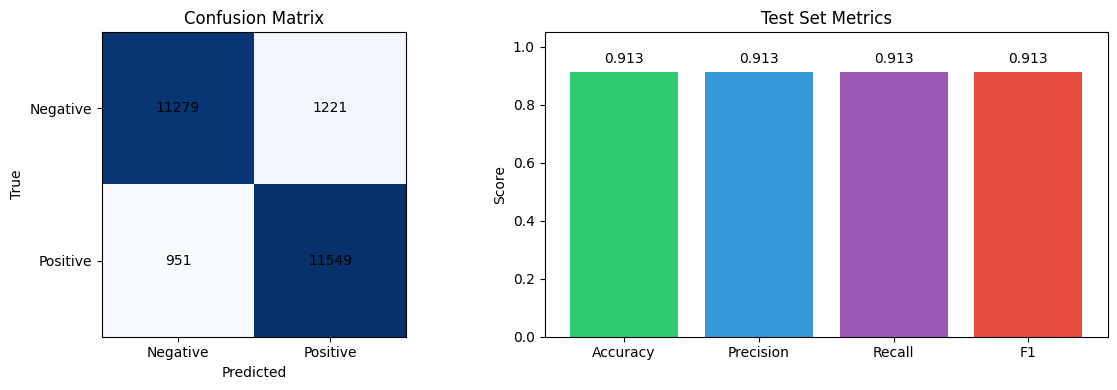

In [ ]:
# ── Self-contained: run in a fresh runtime (no other cells required) ─────────────
import os
import numpy as np
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
try:
    from tqdm.auto import tqdm
except ImportError:
    from tqdm import tqdm

# Device: CUDA > MPS (Apple Silicon) > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Device:", device)

# Load merged model from disk (no training)
MERGED_DIR = "./bert-imdb-lora/merged_model"
tokenizer = AutoTokenizer.from_pretrained(MERGED_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MERGED_DIR, num_labels=2)
model.to(device)
model.eval()

# Tokenize test set (reuse same max_length as training)
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=256,
        padding="max_length",
        return_tensors=None,
    )

# Same 90/10 split as training for fair comparison with encoder-only model
from datasets import concatenate_datasets
ds = load_dataset("imdb")
combined = concatenate_datasets([ds["train"], ds["test"]])
split = combined.train_test_split(test_size=0.10, seed=42, stratify_by_column="label")
val_ds = split["test"]  # 10% validation
test_enc = val_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
test_enc.set_format(type="torch", columns=["input_ids", "attention_mask", "token_type_ids", "label"])

# Get predictions in batches
def collate_fn(batch):
    return {
        "input_ids": torch.stack([x["input_ids"] for x in batch]),
        "attention_mask": torch.stack([x["attention_mask"] for x in batch]),
        "token_type_ids": torch.stack([x["token_type_ids"] for x in batch]),
        "labels": torch.stack([x["label"] for x in batch]),
    }

dataloader = DataLoader(test_enc, batch_size=16, shuffle=False, collate_fn=collate_fn)

all_preds = []
all_labels = []
with torch.no_grad():
    for batch in tqdm(dataloader, desc="Evaluating"):
        labels = batch["labels"].cpu().numpy()
        batch = {k: v.to(device) for k, v in batch.items() if k != "labels"}
        out = model(**batch)
        preds = out.logits.argmax(dim=-1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)


=== LoRA BERT (merged model) — Test set metrics ===

Accuracy:           0.9131
Precision (weighted): 0.9133
Recall (weighted):    0.9131
F1 (weighted):        0.9131

Per-class Precision: negative=0.9222, positive=0.9044
Per-class Recall:    negative=0.9023, positive=0.9239


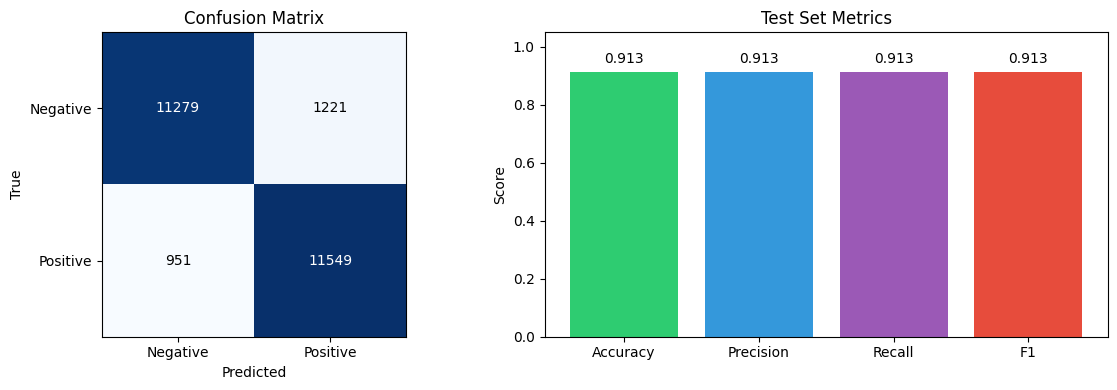

In [ ]:
# Precision, recall, F1
accuracy = accuracy_score(all_labels, all_preds)
precision_weighted = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
recall_weighted = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
f1_weighted = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
precision_per_class = precision_score(all_labels, all_preds, average=None, zero_division=0)
recall_per_class = recall_score(all_labels, all_preds, average=None, zero_division=0)

print("=== LoRA BERT (merged model) — Test set metrics ===\n")
print(f"Accuracy:           {accuracy:.4f}")
print(f"Precision (weighted): {precision_weighted:.4f}")
print(f"Recall (weighted):    {recall_weighted:.4f}")
print(f"F1 (weighted):        {f1_weighted:.4f}")
print(f"\nPer-class Precision: negative={precision_per_class[0]:.4f}, positive={precision_per_class[1]:.4f}")
print(f"Per-class Recall:    negative={recall_per_class[0]:.4f}, positive={recall_per_class[1]:.4f}")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1) Confusion matrix heatmap
ax1 = axes[0]
im = ax1.imshow(cm, cmap="Blues")
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(["Negative", "Positive"])
ax1.set_yticklabels(["Negative", "Positive"])
ax1.set_xlabel("Predicted")
ax1.set_ylabel("True")
for i in range(2):
    for j in range(2):
        text_color = "white" if (i, j) in ((0, 0), (1, 1)) else "black"
        ax1.text(j, i, str(cm[i, j]), ha="center", va="center", color=text_color)
ax1.set_title("Confusion Matrix")

# 2) Metrics bar chart
ax2 = axes[1]
metrics_names = ["Accuracy", "Precision", "Recall", "F1"]
metrics_vals = [accuracy, precision_weighted, recall_weighted, f1_weighted]
colors = ["#2ecc71", "#3498db", "#9b59b6", "#e74c3c"]
bars = ax2.bar(metrics_names, metrics_vals, color=colors)
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("Score")
ax2.set_title("Test Set Metrics")
for bar, val in zip(bars, metrics_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{val:.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

### Optimization techniques used in this notebook

- **LoRA (Low-Rank Adaptation)**  
  Only the low-rank adapter matrices (and the classification head) are trained; the rest of BERT is frozen. This cuts trainable parameters to ~0.27% of the full model and speeds up training while limiting overfitting.

- **Parameter-efficient fine-tuning (PEFT)**  
  Uses `peft` with a small rank (`r=8`), `lora_alpha=16`, and `lora_dropout=0.05` on the `query` and `value` projections in the attention layers.

- **Training**  
  - **Weight decay** (0.01) for L2 regularization.  
  - **Learning rate** 2e-4 with **warmup** (6% of steps) for stable updates.  
  - **Eval/save every epoch** and **load_best_model_at_end** by accuracy to keep the best checkpoint.  
  - **fp16** when CUDA is available to reduce memory and speed up training.

- **Inference**  
  **Merged model**: LoRA weights are merged into the base model and saved as a single checkpoint so inference does not need the PEFT library.

### Precision and recall

Precision and recall (weighted and per-class) are computed and printed above after running the evaluation cell. On the IMDB test set with the saved merged model, you should see **precision and recall both around 0.91** (in line with the reported accuracy and F1 of ~91.3%). Run the evaluation cell above to get the exact values for your saved model.